In [1]:
import pandas as pd 
import os 

In [2]:
prospect = pd.read_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/prospect/prospect_processed.parquet")
len(prospect)

757820

In [3]:
multi_ptm = pd.read_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/multi_ptm/multi_ptm_processed.parquet")
len(multi_ptm)

212179

In [4]:
tmt = pd.read_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/tmt/tmt_processed.parquet")
len(tmt)

588979

In [5]:
tmt_ptm = pd.read_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/tmt_ptm/tmt_ptm_processed.parquet")
len(tmt_ptm)

73219

In [8]:
combined_df = pd.concat([prospect, multi_ptm, tmt, tmt_ptm], axis=0)

In [9]:
len(combined_df)

1632197

In [10]:
unique_combined_df = combined_df.drop_duplicates(subset='modified_sequence', keep='first')
print(f"Number of duplicates removed: {len(combined_df) - len(unique_combined_df)}")

Number of duplicates removed: 10268


In [11]:
len(unique_combined_df)

1621929

In [23]:
unique_combined_df.to_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/combined_data/combined_processed.parquet")

In [24]:
unique_combined_df.columns

Index(['modified_sequence', 'precursor_charge', 'precursor_intensity',
       'raw_file', 'scan_number', 'package', 'charge_by_max_intensity',
       'max_intensity', 'one_hot_most_abundant_charge', 'charge_state_vector',
       'normalized_intensity_distribution'],
      dtype='object')

In [ ]:
unique_combined_df = unique_combined_df['modified_sequence', 'raw_file', 'scan_number', 'package', 'charge_by_max_intensity', 'one_hot_most_abundant_charge']

In [12]:
test_ptm = pd.read_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/test_ptm/test_ptm_processed.parquet")
test_ptm.columns

Index(['modified_sequence', 'precursor_charge', 'precursor_intensity',
       'raw_file', 'scan_number', 'package', 'total_intensity',
       'charge_by_max_intensity', 'max_intensity',
       'one_hot_most_abundant_charge', 'charge_state_vector',
       'normalized_intensity_distribution'],
      dtype='object')

In [13]:
len(test_ptm)

42270

## EDA combined set

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
combined_data = pd.read_parquet("/mnt/c/Users/Florian/Desktop/Uni/MSc/FoPr/PROSPECT/processed_data/combined_data/combined_processed.parquet") # , engine='fastparquet'

ArrowNotImplementedError: Nested data conversions not implemented for chunked array outputs

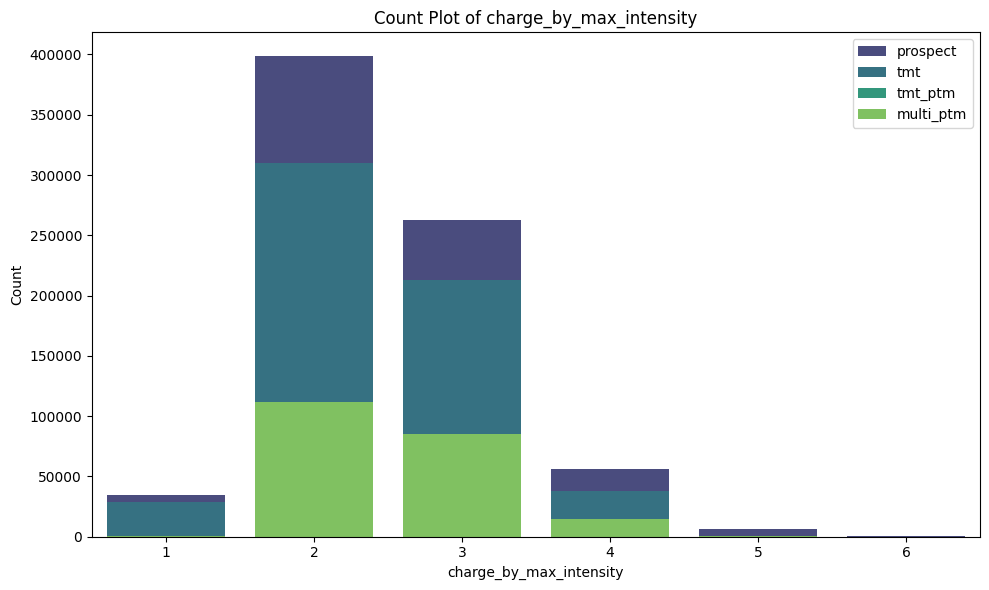

In [8]:
dfs = [prospect, tmt, tmt_ptm, multi_ptm]
labels = ['prospect', 'tmt', 'tmt_ptm', 'multi_ptm']
column_name = 'charge_by_max_intensity'  

palette = sns.color_palette("viridis", 4)

plt.figure(figsize=(10, 6))

for i, df in enumerate(dfs):
    sns.countplot(x=column_name, data=df, color=palette[i], label=labels[i])

plt.legend()
plt.title(f'Count Plot of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Count')
plt.tight_layout()
plt.show()
